<a href="https://colab.research.google.com/github/YYM89/MSSP607/blob/main/Assignment3_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import seaborn as sns
plt.rc('figure', figsize=(8, 10))
np.set_printoptions(precision=4, suppress=True)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [3]:
df = pd.read_csv('/content/drive/MyDrive/MSSP607/Data/HousingPrices.csv', encoding='latin1')
display(df.head(3))

,Id,LotFrontage,LotArea,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,CentralAir,1stFlrSF,2ndFlrSF,FullBath,TotalRooms,GarageCars,GarageArea,YrSold,SalePrice
0,1,65.0,8450.0,2Story,7,5,2003,856.0,Y,856,854,2,8,2,548,2008,208500
1,2,80.0,9600.0,1Story,6,8,1976,NaN,Y,1262,0,2,6,2,460,2007,181500
2,3,68.0,11250.0,2Story,7,5,2001,920.0,Y,920,866,2,6,2,608,2008,223500


In [4]:
#data cleaning
df = df.fillna(0)

In [5]:
df.isnull().sum()

,0
Id,0
LotFrontage,0
LotArea,0
HouseStyle,0
OverallQual,0
OverallCond,0
YearBuilt,0
TotalBsmtSF,0
CentralAir,0
1stFlrSF,0


In [6]:
#Calculate
price_mean = round(df['SalePrice'].mean(),2)
price_std = round(df['SalePrice'].std(),2)
price_median = round(df['SalePrice'].median(),2)
price_min =round( df['SalePrice'].min(),2)
price_max = round(df['SalePrice'].max(),2)
price_coe = round((price_std / price_mean) * 100,2)
print('Mean:', price_mean)
print('Standard Deviation:', price_std)
print('Median:', price_median)
print('Min:', price_min)
print('Max:', price_max)
print('Coefficient of Variation:', price_coe)

Mean: 180921.2
Standard Deviation: 79442.5
Median: 163000.0
Min: 34900
Max: 755000
Coefficient of Variation: 43.91


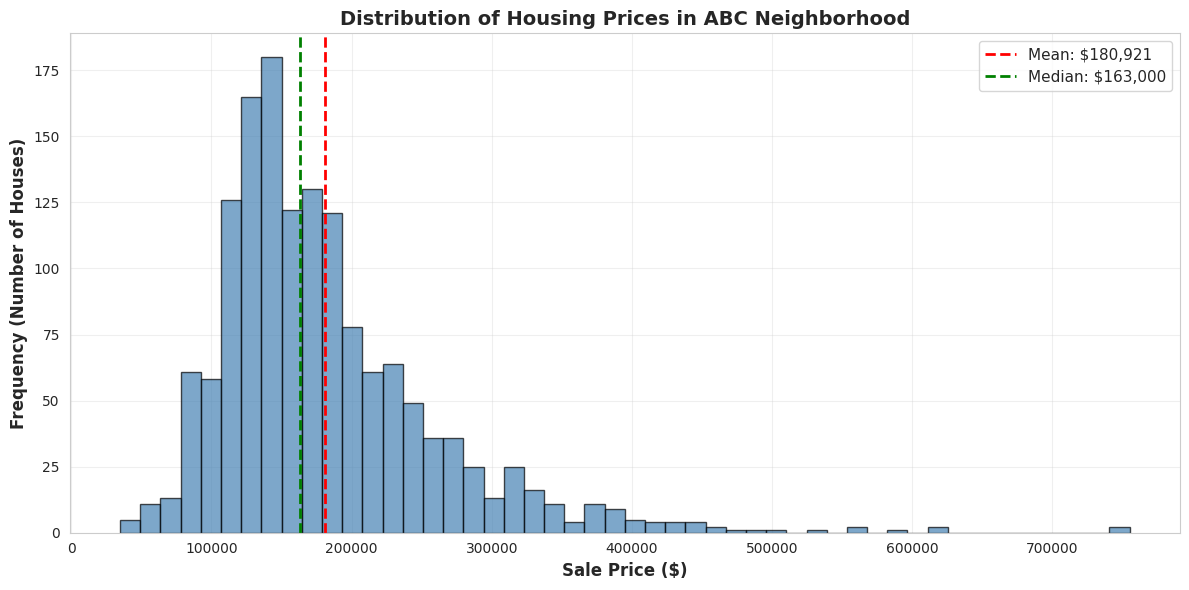

In [7]:
#Histogram
plt.figure(figsize=(12, 6))
plt.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(price_mean, color='red', linestyle='--', linewidth=2,
            label=f'Mean: ${price_mean:,.0f}')
plt.axvline(price_median, color='green', linestyle='--', linewidth=2,
            label=f'Median: ${price_median:,.0f}')

plt.xlabel('Sale Price ($)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (Number of Houses)', fontsize=12, fontweight='bold')
plt.title('Distribution of Housing Prices in ABC Neighborhood',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

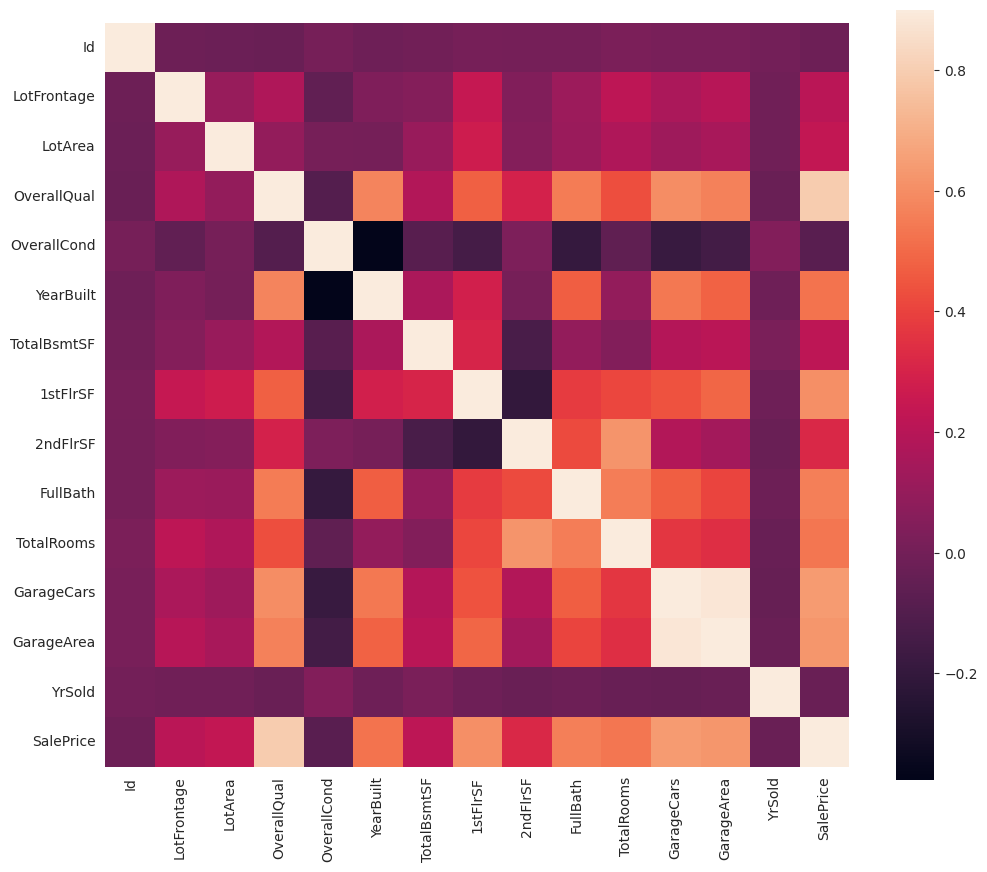

In [8]:
# 1. cor matrix
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, vmax=0.9, square=True)
plt.show()

In [9]:
correlations = corr_matrix['SalePrice'].sort_values(ascending=False)
print("Top correlations with SalePrice:")
print(correlations[1:11])

top_feature_1 = correlations.index[1]
top_feature_2 = correlations.index[2]

print(f"\nMost correlated features with SalePrice:")
print(f"1. {top_feature_1}: {correlations[1]:.3f}")
print(f"2. {top_feature_2}: {correlations[2]:.3f}")


Top correlations with SalePrice:
OverallQual    0.790982
GarageCars     0.640409
GarageArea     0.623431
1stFlrSF       0.605852
FullBath       0.560664
TotalRooms     0.533723
YearBuilt      0.522897
2ndFlrSF       0.319334
LotArea        0.235751
TotalBsmtSF    0.218204
Name: SalePrice, dtype: float64

Most correlated features with SalePrice:
1. OverallQual: 0.791
2. GarageCars: 0.640


/tmp/ipython-input-1215983842.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"1. {top_feature_1}: {correlations[1]:.3f}")
/tmp/ipython-input-1215983842.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"2. {top_feature_2}: {correlations[2]:.3f}")


In [13]:
# Z-scores
z_scores = np.abs(stats.zscore(df['SalePrice']))
outliers_zscore = df[z_scores > 3].copy()
print(f"Total Outliers (Z-score > 3): {len(outliers_zscore)}")
display(outliers_zscore.head(3))

Total Outliers (Z-score > 3): 22


,Id,LotFrontage,LotArea,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,CentralAir,1stFlrSF,2ndFlrSF,FullBath,TotalRooms,GarageCars,GarageArea,YrSold,SalePrice
58,59,66.0,13682.0,2Story,10,5,2006,0.0,Y,1426,1519,3,10,3,641,2006,438780
178,179,63.0,17423.0,1Story,9,5,2008,0.0,Y,2234,0,2,9,3,1166,2009,501837
185,186,90.0,22950.0,2.5Fin,10,9,1892,1107.0,Y,1518,1518,2,12,3,840,2006,475000


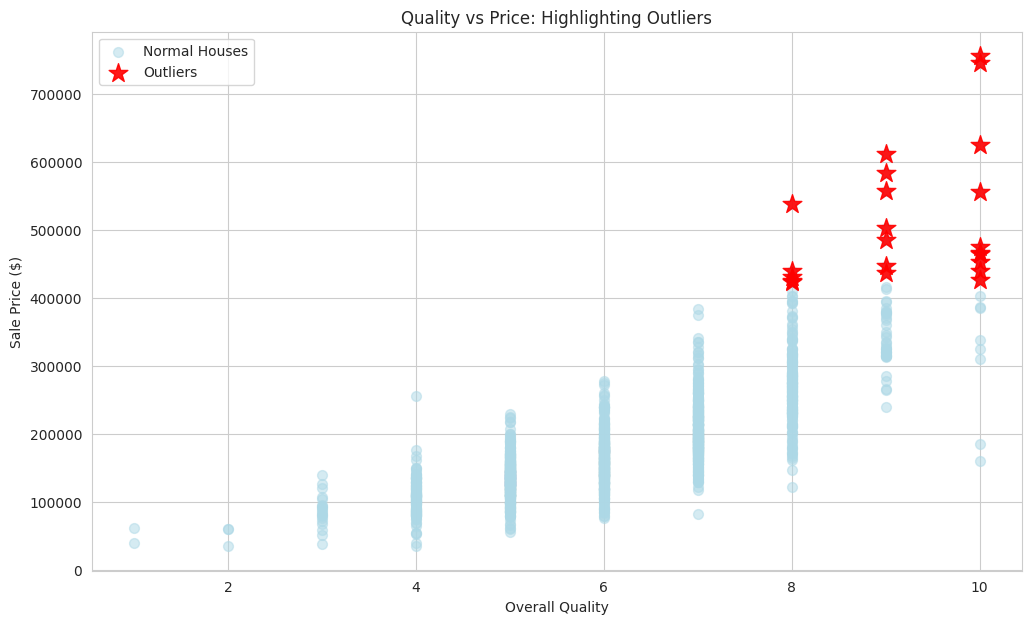

In [11]:
plt.figure(figsize=(12, 7))
plt.scatter(df['OverallQual'], df['SalePrice'], alpha=0.5, s=50,
            color='lightblue', label='Normal Houses')
plt.scatter(outliers_zscore['OverallQual'], outliers_zscore['SalePrice'],
            alpha=0.9, s=200, color='red', label='Outliers', marker='*')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price ($)')
plt.title('Quality vs Price: Highlighting Outliers')
plt.legend()
plt.show()

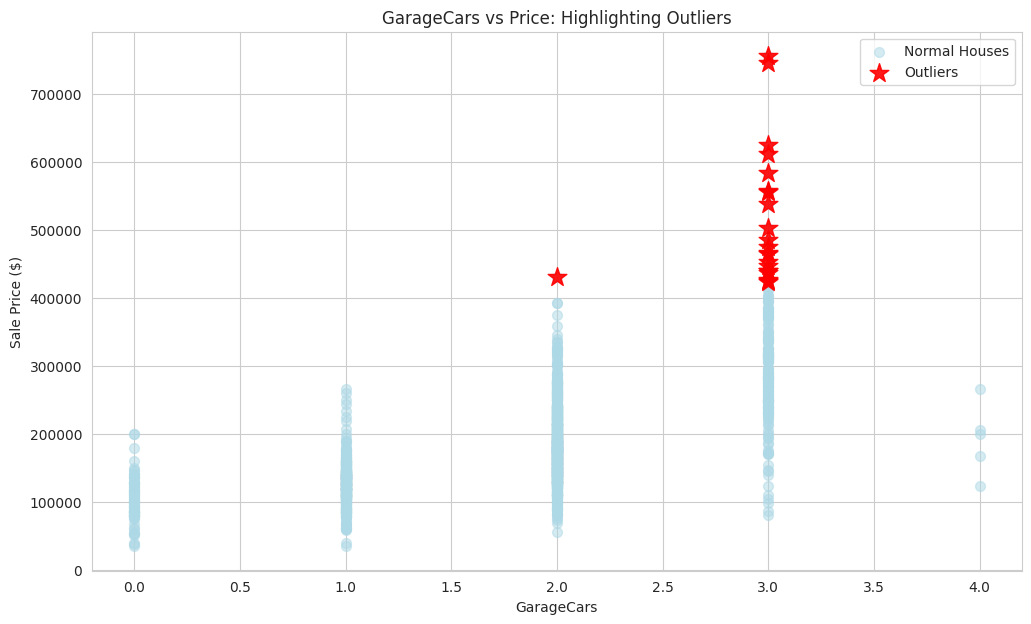

In [12]:
plt.figure(figsize=(12, 7))
plt.scatter(df['GarageCars'], df['SalePrice'], alpha=0.5, s=50,
            color='lightblue', label='Normal Houses')
plt.scatter(outliers_zscore['GarageCars'], outliers_zscore['SalePrice'],
            alpha=0.9, s=200, color='red', label='Outliers', marker='*')
plt.xlabel('GarageCars')
plt.ylabel('Sale Price ($)')
plt.title('GarageCars vs Price: Highlighting Outliers')
plt.legend()
plt.show()